In [2]:
import os
import zipfile

# If the file is in your Downloads folder, set the path here:
# zip_path = os.path.expanduser("~/Downloads/consep.zip") 
# Or if you moved it to your current notebook folder:
zip_path = "consep.zip" if os.path.exists("consep.zip") else "archive.zip"

extract_to = "dataset"

print(f"Extracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extraction complete!")

Extracting archive.zip...
Extraction complete!


In [3]:
import os

for root, dirs, files in os.walk("dataset"):
    # Show only directories to keep output tidy
    level = root.replace("dataset", "").count(os.sep)
    if level <= 3:
        indent = " " * 4 * level
        print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")

dataset/ (0 files)
    CoNSeP/ (1 files)
        Test/ (0 files)
            Images/ (14 files)
            Labels/ (14 files)
            Overlay/ (14 files)
        Train/ (0 files)
            Images/ (27 files)
            Labels/ (27 files)
            Overlay/ (27 files)


In [4]:
import os
import scipy.io as sio
import numpy as np

# Find train_1.mat automatically
mat_path = None
for root, dirs, files in os.walk("dataset"):
    if "train_1.mat" in files:
        mat_path = os.path.join(root, "train_1.mat")
        break

if mat_path:
    print(f"Found annotation file at: {mat_path}")
    data = sio.loadmat(mat_path)
    
    # Check keys
    keys = [k for k in data.keys() if not k.startswith("__")]
    print("Variables in .mat file:", keys)
    
    # Check type_map
    type_map = data['type_map']
    unique_types = np.unique(type_map)
    print(f"Unique classes in type_map: {unique_types}")
    print(f"Class 4 (Malignant) present: {4 in unique_types}")
else:
    print("Could not find train_1.mat. Check Step 2 output to see where files were placed.")

Found annotation file at: dataset\CoNSeP\Train\Labels\train_1.mat
Variables in .mat file: ['inst_map', 'type_map', 'inst_type', 'inst_centroid']
Unique classes in type_map: [0. 1. 2. 4. 5.]
Class 4 (Malignant) present: True


In [7]:
import os
import glob
import cv2
import scipy.io as sio
import numpy as np

# Define directories
BASE_RAW = "dataset/CoNSeP"  # Adjust if folder name is slightly different
PROCESSED_DIR = "dataset/processed"

for split in ["train", "test"]:
    os.makedirs(f"{PROCESSED_DIR}/{split}/images", exist_ok=True)
    os.makedirs(f"{PROCESSED_DIR}/{split}/masks", exist_ok=True)

def process_split(split_name, raw_folder_name, patch_size=256, stride=128):
    img_paths = sorted(glob.glob(f"{BASE_RAW}/{raw_folder_name}/Images/*.png"))
    label_paths = sorted(glob.glob(f"{BASE_RAW}/{raw_folder_name}/Labels/*.mat"))
    
    patch_count = 0
    
    for img_p, lbl_p in zip(img_paths, label_paths):
        base_name = os.path.splitext(os.path.basename(img_p))[0]
        
        # Load image (RGB)
        img = cv2.imread(img_p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Load mat file
        mat = sio.loadmat(lbl_p)
        inst_map = mat['inst_map']
        
        # Create binary mask (0 = Background, 255 = Nucleus)
        binary_mask = (inst_map > 0).astype(np.uint8) * 255
        
        h, w, _ = img.shape
        
        # Tile into patches
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                img_patch = img[y:y+patch_size, x:x+patch_size]
                mask_patch = binary_mask[y:y+patch_size, x:x+patch_size]
                
                # Filter out patches that are almost entirely empty background
                if np.sum(mask_patch > 0) > 50:  # Must have at least a few nuclei pixels
                    save_name = f"{base_name}_y{y}_x{x}.png"
                    
                    # Save image and mask patches
                    cv2.imwrite(f"{PROCESSED_DIR}/{split_name}/images/{save_name}", 
                                cv2.cvtColor(img_patch, cv2.COLOR_RGB2BGR))
                    cv2.imwrite(f"{PROCESSED_DIR}/{split_name}/masks/{save_name}", mask_patch)
                    patch_count += 1
                    
    print(f"Generated {patch_count} patches for {split_name} split.")

# Run for both Train and Test
process_split("train", "Train", patch_size=256, stride=128)
process_split("test", "Test", patch_size=256, stride=256)

Generated 933 patches for train split.
Generated 125 patches for test split.


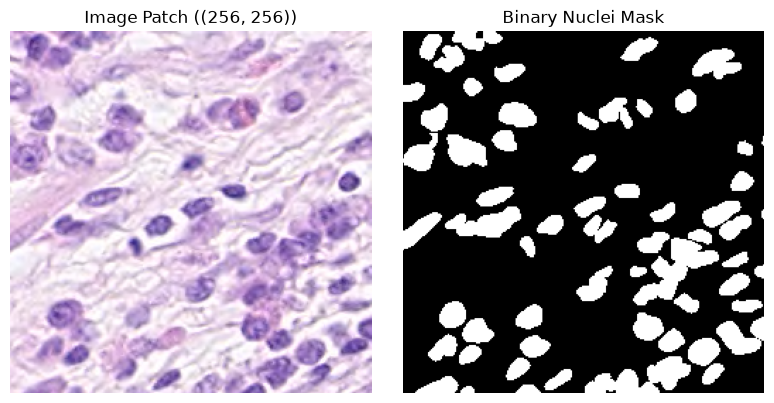

In [8]:
import matplotlib.pyplot as plt
import random

train_imgs = sorted(glob.glob(f"{PROCESSED_DIR}/train/images/*.png"))
sample_idx = random.randint(0, len(train_imgs) - 1)

sample_img = cv2.cvtColor(cv2.imread(train_imgs[sample_idx]), cv2.COLOR_BGR2RGB)
sample_mask = cv2.imread(train_imgs[sample_idx].replace("images", "masks"), cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample_img)
ax[0].set_title(f"Image Patch ({sample_img.shape[:2]})")
ax[0].axis("off")

ax[1].imshow(sample_mask, cmap="gray")
ax[1].set_title("Binary Nuclei Mask")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
import os
import glob
import cv2
import scipy.io as sio
import numpy as np

# 1. Automatically find where CoNSeP Train/Test folders are located
base_search = glob.glob("dataset/**/Train/Images", recursive=True)
if not base_search:
    raise FileNotFoundError("Could not find CoNSeP Train/Images folder inside dataset/. Check folder structure.")

consep_root = os.path.dirname(os.path.dirname(base_search[0]))
print(f"Located CoNSeP root at: {consep_root}")

# 2. Output directory for patches
PROCESSED_DIR = "dataset/processed"
for split in ["train", "test"]:
    os.makedirs(f"{PROCESSED_DIR}/{split}/images", exist_ok=True)
    os.makedirs(f"{PROCESSED_DIR}/{split}/masks", exist_ok=True)

def extract_patches(split_dir_name, save_split_name, patch_size=256, stride=128):
    img_paths = sorted(glob.glob(os.path.join(consep_root, split_dir_name, "Images", "*.png")))
    lbl_paths = sorted(glob.glob(os.path.join(consep_root, split_dir_name, "Labels", "*.mat")))
    
    print(f"Processing {len(img_paths)} images from {split_dir_name}...")
    total_patches = 0
    
    for img_p, lbl_p in zip(img_paths, lbl_paths):
        base_name = os.path.splitext(os.path.basename(img_p))[0]
        
        img = cv2.imread(img_p)
        mat = sio.loadmat(lbl_p)
        inst_map = mat['inst_map']
        
        # Binarize: nucleus (>0) -> 255, background (0) -> 0
        binary_mask = (inst_map > 0).astype(np.uint8) * 255
        
        h, w, _ = img.shape
        
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                img_patch = img[y:y+patch_size, x:x+patch_size]
                mask_patch = binary_mask[y:y+patch_size, x:x+patch_size]
                
                # Keep patches that contain at least some nuclei pixels
                if np.sum(mask_patch > 0) > 50:
                    patch_id = f"{base_name}_y{y}_x{x}.png"
                    cv2.imwrite(f"{PROCESSED_DIR}/{save_split_name}/images/{patch_id}", img_patch)
                    cv2.imwrite(f"{PROCESSED_DIR}/{save_split_name}/masks/{patch_id}", mask_patch)
                    total_patches += 1
                    
    print(f"Finished {save_split_name}: {total_patches} patches created.")

# Run patch generation
extract_patches("Train", "train", patch_size=256, stride=128)
extract_patches("Test", "test", patch_size=256, stride=256)

Located CoNSeP root at: dataset\CoNSeP
Processing 27 images from Train...
Finished train: 933 patches created.
Processing 14 images from Test...
Finished test: 125 patches created.


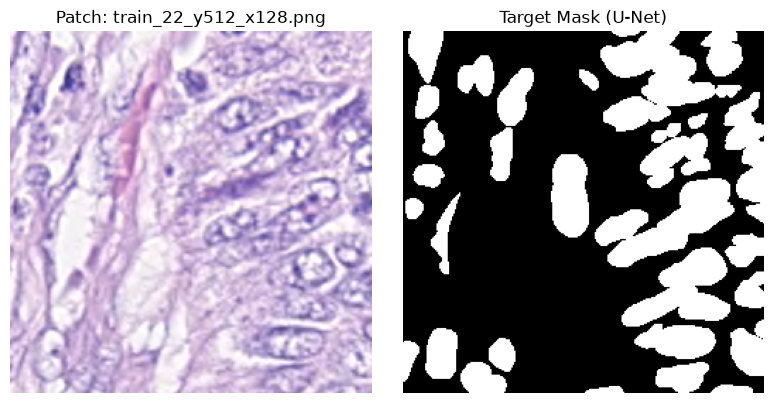